# Downscaling Data Exploration

This notebook follows the experiment brief in `Data 8 Mar 2026.docx` and is now written against the files that already exist under `data/`.

We use:
- `ERA5-Land` daily `t2m` files for 1990-1999 as the target dataset.
- `CMIP6` historical `tas_day` for 1990-1999 as the main coarse predictor example.
- `ERA5` 1990 `t2m` as an optional supporting reanalysis file.

Each block below states **what we are checking** and **why it matters**.

## 1. Environment Check

**What we are checking:** that Python can read the NetCDF/HDF5 files that were added to the project.

**Why:** the new data files are real NetCDF/HDF5 datasets, so the notebook must confirm the required IO support before doing any analysis.

In [18]:
from pathlib import Path
import importlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

required_modules = ["netCDF4", "h5netcdf"]
module_status = {name: importlib.util.find_spec(name) is not None for name in required_modules}
display(pd.DataFrame({"module": list(module_status), "available": list(module_status.values())}))

if not any(module_status.values()):
    raise RuntimeError(
        "No NetCDF backend is available. Install `netCDF4` or `h5netcdf` before running the notebook."
    )

,module,available
0,netCDF4,True
1,h5netcdf,True


## 2. Inventory the Actual Files We Have

**What we are checking:** which files are already present locally and how they map to the sources described in the brief.

**Why:** the previous notebook assumed a minimal fetch flow, but now we should work directly from the files that are already in the project.

In [19]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_DIR = PROJECT_ROOT / "data"

ERA5_LAND_FILES = sorted([
    path for path in DATA_DIR.glob("t2m_ERA5land_daily_*.nc")
    if "(1)" not in path.name
])
CMIP_FILE = DATA_DIR / "tas_day_CESM2-WACCM_historical_r1i1p1f1_gn_19900101-19991231.nc"
ERA5_FILE = DATA_DIR / "raw" / "era5" / "t2m_day_levels_era5_MJJAS_19900101-19901231.nc"

manifest = pd.DataFrame([
    {
        "dataset": "ERA5-Land target (1990-1999)",
        "n_files": len(ERA5_LAND_FILES),
        "path_or_example": str(ERA5_LAND_FILES[0]) if ERA5_LAND_FILES else "missing",
        "source_in_doc": "Copernicus CDS / Ronit's annual files",
    },
    {
        "dataset": "CMIP6 predictor",
        "n_files": int(CMIP_FILE.exists()),
        "path_or_example": str(CMIP_FILE),
        "source_in_doc": "ESGF / Anton shared file",
    },
    {
        "dataset": "ERA5 supporting reanalysis",
        "n_files": int(ERA5_FILE.exists()),
        "path_or_example": str(ERA5_FILE),
        "source_in_doc": "Andre shared ERA5 path",
    },
])

manifest

,dataset,n_files,path_or_example,source_in_doc
0,ERA5-Land target (1990-1999),10,/Users/shirke/Desktop/Thesis/data/t2m_ERA5land...,Copernicus CDS / Ronit's annual files
1,CMIP6 predictor,1,/Users/shirke/Desktop/Thesis/data/tas_day_CESM...,ESGF / Anton shared file
2,ERA5 supporting reanalysis,1,/Users/shirke/Desktop/Thesis/data/raw/era5/t2m...,Andre shared ERA5 path


## 3. Open the Datasets and Harmonize Their Basic Structure

**What we are checking:** the real variable names, coordinate names, and time-coordinate conventions inside the files.

**Why:** the brief warns about calendar and alignment issues, and these files confirm that the datasets do not all use the same conventions. In particular, `ERA5-Land` uses `valid_time` while `CMIP6` uses `time` with a no-leap calendar.

In [20]:
if not ERA5_LAND_FILES:
    raise RuntimeError("No ERA5-Land annual files were found under data/.")
if not CMIP_FILE.exists():
    raise RuntimeError("The CMIP sample file is missing from data/.")


def open_dataset(path):
    try:
        return xr.open_dataset(path, engine="netcdf4")
    except Exception:
        return xr.open_dataset(path, engine="h5netcdf")


def prepare_era5land_file(path):
    ds = open_dataset(path)
    rename_map = {}
    if "valid_time" in ds.coords:
        rename_map["valid_time"] = "time"
    if rename_map:
        ds = ds.rename(rename_map)
    drop_names = [name for name in ["number", "expver"] if name in ds.coords or name in ds.variables]
    if drop_names:
        ds = ds.drop_vars(drop_names)
    return ds[["t2m"]]


era5_land_list = [prepare_era5land_file(path) for path in ERA5_LAND_FILES]
era5_land_ds = xr.concat(era5_land_list, dim="time").sortby("time")
cmip_ds = open_dataset(CMIP_FILE)
era5_ds = open_dataset(ERA5_FILE) if ERA5_FILE.exists() else None
if era5_ds is not None and "valid_time" in era5_ds.coords:
    era5_ds = era5_ds.rename({"valid_time": "time"})
if era5_ds is not None:
    drop_names = [name for name in ["number", "expver"] if name in era5_ds.coords or name in era5_ds.variables]
    if drop_names:
        era5_ds = era5_ds.drop_vars(drop_names)

structure_summary = pd.DataFrame([
    {
        "dataset": "ERA5-Land target",
        "variables": ", ".join(era5_land_ds.data_vars),
        "dims": str(dict(era5_land_ds.sizes)),
        "time_coord": "time",
    },
    {
        "dataset": "CMIP6 predictor",
        "variables": ", ".join(cmip_ds.data_vars),
        "dims": str(dict(cmip_ds.sizes)),
        "time_coord": "time",
    },
    {
        "dataset": "ERA5 supporting file",
        "variables": ", ".join(era5_ds.data_vars) if era5_ds is not None else "missing",
        "dims": str(dict(era5_ds.sizes)) if era5_ds is not None else "missing",
        "time_coord": "time" if era5_ds is not None else "missing",
    },
])

structure_summary

,dataset,variables,dims,time_coord
0,ERA5-Land target,t2m,"{'time': 3652, 'latitude': 141, 'longitude': 81}",time
1,CMIP6 predictor,"tas, time_bnds, lat_bnds, lon_bnds","{'time': 3650, 'lat': 192, 'lon': 288, 'nbnd': 2}",time
2,ERA5 supporting file,t2m,"{'time': 153, 'latitude': 241, 'longitude': 461}",time


In [21]:
def metadata_and_sample(ds, dataset_name, variable_name):
    arr = ds[variable_name]
    dataset_keys = [
        "Conventions",
        "institution",
        "source",
        "experiment_id",
        "frequency",
        "grid",
        "nominal_resolution",
        "variable_id",
        "history",
    ]
    variable_keys = [
        "long_name",
        "standard_name",
        "units",
        "cell_methods",
        "comment",
        "GRIB_name",
        "GRIB_units",
        "GRIB_gridType",
        "GRIB_iDirectionIncrementInDegrees",
        "GRIB_jDirectionIncrementInDegrees",
    ]
    selected_ds_attrs = {key: ds.attrs[key] for key in dataset_keys if key in ds.attrs}
    selected_var_attrs = {key: arr.attrs[key] for key in variable_keys if key in arr.attrs}

    print(f"\n===== {dataset_name} =====")
    print("Selected dataset attributes:")
    for key, value in selected_ds_attrs.items():
        print(f"- {key}: {value}")

    print("\nSelected variable attributes:")
    for key, value in selected_var_attrs.items():
        print(f"- {key}: {value}")

    print("\nCoordinate sample:")
    for coord_name in arr.dims:
        coord = ds[coord_name].values
        print(f"- {coord_name}: first={coord[0]!r}, last={coord[-1]!r}, n={len(coord)}")

    print("\nSmall value sample:")
    sample = arr.isel({dim: slice(0, min(2, arr.sizes[dim])) for dim in arr.dims}).values
    print(sample)


metadata_and_sample(cmip_ds, "CMIP6 predictor", "tas")
metadata_and_sample(era5_land_ds, "ERA5-Land target", "t2m")
if era5_ds is not None:
    metadata_and_sample(era5_ds, "ERA5 supporting file", "t2m")


===== CMIP6 predictor =====
Selected dataset attributes:
- Conventions: CF-1.7 CMIP-6.2
- institution: National Center for Atmospheric Research, Climate and Global Dynamics Laboratory, 1850 Table Mesa Drive, Boulder, CO 80305, USA
- source: CESM2 (2017): atmosphere: CAM6 (0.9x1.25 finite volume grid; 288 x 192 longitude/latitude; 70 levels; top level 4.5e-6 mb); ocean: POP2 (320x384 longitude/latitude; 60 levels; top grid cell 0-10 m); sea_ice: CICE5.1 (same grid as ocean); land: CLM5 0.9x1.25 finite volume grid; 288 x 192 longitude/latitude; 70 levels; top level 4.5e-6 mb); aerosol: MAM4 (0.9x1.25 finite volume grid; 288 x 192 longitude/latitude; 70 levels; top level 4.5e-6 mb); atmosChem: WACCM (0.9x1.25 finite volume grid; 288 x 192 longitude/latitude; 70 levels; top level 4.5e-6 mb; landIce: CISM2.1; ocnBgchem: MARBL (320x384 longitude/latitude; 60 levels; top grid cell 0-10 m)
- experiment_id: historical
- frequency: day
- grid: native 0.9x1.25 finite volume grid (192x288 latxlon

### How To Read The Selected Metadata

- `Conventions`: which metadata standard the file follows. This tells us how coordinates, units, and dimensions are encoded.
- `institution` and `source`: who produced the dataset and from which climate model or reanalysis system it came.
- `experiment_id`: the CMIP experiment or scenario. For example, `historical` means a past-climate simulation.
- `frequency`: the time resolution of the file, such as daily data.
- `grid` and `nominal_resolution`: how coarse or fine the spatial grid is. This matters directly for downscaling.
- `variable_id`: the official short variable name used by the dataset.
- `history`: how the file was generated or transformed before it reached us.

- `long_name`: a readable name for the variable.
- `standard_name`: the CF-standard scientific meaning of the variable, when available.
- `units`: how the values are measured, for example Kelvin.
- `cell_methods`: whether the variable is instantaneous or averaged over time.
- `comment`: extra scientific context about what the variable represents.
- `GRIB_*` fields: source-specific metadata from ECMWF/GRIB files. Here, the most useful ones are the grid type and the latitude/longitude increments because they describe the native ERA grid.

For this notebook, the key variables are `t2m` on the observed/reanalysis side and `tas` on the CMIP6 side. The coordinate sample shows the grid extent and ordering, and the small value sample helps us sanity-check that the numbers look physically reasonable.

## 4. Check Temporal Coverage and Calendar Behavior

**What we are checking:** date ranges, leap days, and the overlap period between the target and the CMIP predictor.

**Why:** the brief explicitly warns that `CMIP6` typically uses a no-leap calendar, while `ERA5-Land` includes 29 February. We need to see that directly before aligning datasets.

In [22]:
def time_report(ds, label):
    time_strings = pd.Series(ds["time"].values).astype(str)
    parsed = pd.to_datetime(time_strings, errors="coerce")
    return {
        "dataset": label,
        "n_time_steps": len(time_strings),
        "start": time_strings.iloc[0],
        "end": time_strings.iloc[-1],
        "contains_feb_29": bool(((parsed.dt.month == 2) & (parsed.dt.day == 29)).fillna(False).any()),
    }


calendar_report = [
    time_report(era5_land_ds, "ERA5-Land target"),
    time_report(cmip_ds, "CMIP6 predictor"),
]
if era5_ds is not None:
    calendar_report.append(time_report(era5_ds, "ERA5 support"))

calendar_report = pd.DataFrame(calendar_report)
calendar_report

,dataset,n_time_steps,start,end,contains_feb_29
0,ERA5-Land target,3652,1990-01-01,1999-12-31,True
1,CMIP6 predictor,3650,1990-01-01 00:00:00,1999-12-31 00:00:00,False
2,ERA5 support,153,1990-05-01 12:00:00,1990-09-30 12:00:00,False


## 5. Check the Spatial Domain and Needed Alignment Logic

**What we are checking:** spatial resolution, coordinate ranges, and how much coarser the CMIP grid is than the target grid.

**Why:** this is the core downscaling problem. The brief emphasizes that the CMIP grid is coarse and that the fine target grid needs to be aligned carefully to it.

In [23]:
REGION = {"south": 24, "north": 38, "west": 30, "east": 38}


def standardize_longitude(ds, lon_name):
    lon = ds[lon_name]
    if float(lon.max()) > 180:
        ds = ds.assign_coords({lon_name: (((lon + 180) % 360) - 180)})
        ds = ds.sortby(lon_name)
    return ds


def coord_spacing(ds, coord_name):
    values = np.asarray(ds[coord_name].values, dtype=float)
    return float(np.nanmedian(np.abs(np.diff(values))))


def subset_box(ds, lat_name, lon_name, region, pad_lat=0.0, pad_lon=0.0):
    lat_vals = ds[lat_name].values
    lat_slice = slice(region["north"] + pad_lat, region["south"] - pad_lat)
    if lat_vals[0] < lat_vals[-1]:
        lat_slice = slice(region["south"] - pad_lat, region["north"] + pad_lat)
    lon_slice = slice(region["west"] - pad_lon, region["east"] + pad_lon)
    return ds.sel({lat_name: lat_slice, lon_name: lon_slice})


era5_land_ds = standardize_longitude(era5_land_ds, "longitude")
cmip_ds = standardize_longitude(cmip_ds, "lon")
if era5_ds is not None:
    era5_ds = standardize_longitude(era5_ds, "longitude")

cmip_pad_lat = coord_spacing(cmip_ds, "lat") / 2
cmip_pad_lon = coord_spacing(cmip_ds, "lon") / 2

era5_land_region = subset_box(era5_land_ds, "latitude", "longitude", REGION)
cmip_region = subset_box(cmip_ds, "lat", "lon", REGION, pad_lat=cmip_pad_lat, pad_lon=cmip_pad_lon)
era5_region = subset_box(era5_ds, "latitude", "longitude", REGION) if era5_ds is not None else None

spatial_report = pd.DataFrame([
    {
        "dataset": "ERA5-Land target",
        "lat_range": f"{float(era5_land_region.latitude.min()):.2f} to {float(era5_land_region.latitude.max()):.2f}",
        "lon_range": f"{float(era5_land_region.longitude.min()):.2f} to {float(era5_land_region.longitude.max()):.2f}",
        "lat_spacing": coord_spacing(era5_land_region, "latitude"),
        "lon_spacing": coord_spacing(era5_land_region, "longitude"),
    },
    {
        "dataset": "CMIP6 predictor",
        "lat_range": f"{float(cmip_region.lat.min()):.2f} to {float(cmip_region.lat.max()):.2f}",
        "lon_range": f"{float(cmip_region.lon.min()):.2f} to {float(cmip_region.lon.max()):.2f}",
        "lat_spacing": coord_spacing(cmip_region, "lat"),
        "lon_spacing": coord_spacing(cmip_region, "lon"),
    },
])

spatial_report

,dataset,lat_range,lon_range,lat_spacing,lon_spacing
0,ERA5-Land target,24.00 to 38.00,30.00 to 38.00,0.100000,0.10
1,CMIP6 predictor,24.03 to 38.17,30.00 to 37.50,0.942408,1.25


### Why We Add Padding Here

This block prepares the datasets for a fair spatial comparison.

First, we standardize longitude because climate datasets do not always use the same longitude convention. One file may store longitudes as `0` to `360`, while another uses `-180` to `180`. If we do not fix that, the same physical location can appear under different coordinate values.

Next, we estimate the grid spacing from the latitude and longitude coordinates. This tells us the approximate size of one grid cell. `ERA5-Land` has a fine grid, while `CMIP6` has a much coarser grid.

The padding is added only to the `CMIP6` subset. We set the padding to half of one coarse grid cell in latitude and half of one coarse grid cell in longitude. We do this because the coordinates in climate files usually represent the **center** of each grid cell, not the edges.

That means a CMIP cell whose center lies just outside the region can still physically overlap the region of interest. If we subset the coarse file strictly to `24-38` latitude and `30-38` longitude without padding, we may accidentally drop border CMIP cells that still cover part of the target area.

We add padding when we want to preserve those overlapping border cells before any merge or aggregation step. This is especially important in downscaling, because later we may assign many fine `ERA5-Land` pixels to one coarse CMIP cell. If the border coarse cells were removed too early, the alignment would be incomplete near the edges.

So the idea is: use the exact target box for the fine data, but use a slightly expanded box for the coarse data when the coarse coordinates represent pixel centers. That is the safest way to avoid losing relevant coarse-grid coverage at the borders.

## 6. Convert Temperature to Celsius and Check Missingness

**What we are checking:** whether the temperatures are stored in Kelvin, what their rough value ranges are, and how much missing data exists.

**Why:** the brief notes that units and missingness need attention before modeling, especially for the target dataset.

In [24]:
def to_celsius(arr):
    units = str(arr.attrs.get("units", "")).lower()
    if units in {"k", "kelvin"} or float(arr.mean().values) > 150:
        out = arr - 273.15
        out.attrs["units"] = "degC"
        return out
    return arr


era5_land_temp = to_celsius(era5_land_region["t2m"])
cmip_temp = to_celsius(cmip_region["tas"])
era5_temp = to_celsius(era5_region["t2m"]) if era5_region is not None else None

range_report = pd.DataFrame([
    {
        "dataset": "ERA5-Land target",
        "min_c": float(era5_land_temp.min().values),
        "mean_c": float(era5_land_temp.mean().values),
        "max_c": float(era5_land_temp.max().values),
        "missing_fraction": float(era5_land_temp.isnull().mean().values),
        "missing_totals": int(era5_land_temp.isnull().sum().values)
    },
    {
        "dataset": "CMIP6 predictor",
        "min_c": float(cmip_temp.min().values),
        "mean_c": float(cmip_temp.mean().values),
        "max_c": float(cmip_temp.max().values),
        "missing_fraction": float(cmip_temp.isnull().mean().values),
        "missing_totals": int(cmip_temp.isnull().sum().values)
    },
])
if era5_temp is not None:
    range_report = pd.concat([
        range_report,
        pd.DataFrame([{
            "dataset": "ERA5 support",
            "min_c": float(era5_temp.min().values),
            "mean_c": float(era5_temp.mean().values),
            "max_c": float(era5_temp.max().values),
            "missing_fraction": float(era5_temp.isnull().mean().values),
            "missing_totals": int(era5_temp.isnull().sum().values)
        }]),
    ], ignore_index=True)

range_report

,dataset,min_c,mean_c,max_c,missing_fraction,missing_totals
0,ERA5-Land target,-21.272430,19.187107,40.575165,0.327292,13651176
1,CMIP6 predictor,-14.700958,20.522608,41.501160,0.000000,0
2,ERA5 support,-1.519440,29.702261,45.075348,0.000000,0


### 6b. ERA5-Land Missing Value Pattern Investigation

**What we are checking:** whether the ~33% missing values in ERA5-Land follow a temporal pattern (specific date range, year, season) or a spatial pattern (specific latitude/longitude bands or pixels).

**Why:** if missingness is concentrated in particular dates or grid cells, it likely reflects a structural data issue (e.g. land-sea mask, file corruption, retrieval gap) rather than random noise, and we need to know the extent before modeling.

=== Days with ANY missing pixels ===
  3652 / 3652 days

=== Days with ALL pixels missing ===
  0 / 3652 days

=== Missing fraction per year (mean over days) ===


,mean,min,max
year,,,
1990,0.327,0.327,0.327
1991,0.327,0.327,0.327
1992,0.327,0.327,0.327
1993,0.327,0.327,0.327
1994,0.327,0.327,0.327
1995,0.327,0.327,0.327
1996,0.327,0.327,0.327
1997,0.327,0.327,0.327
1998,0.327,0.327,0.327



=== First/last date with missing > 0 ===
  First: 1990-01-01   Last: 1999-12-31


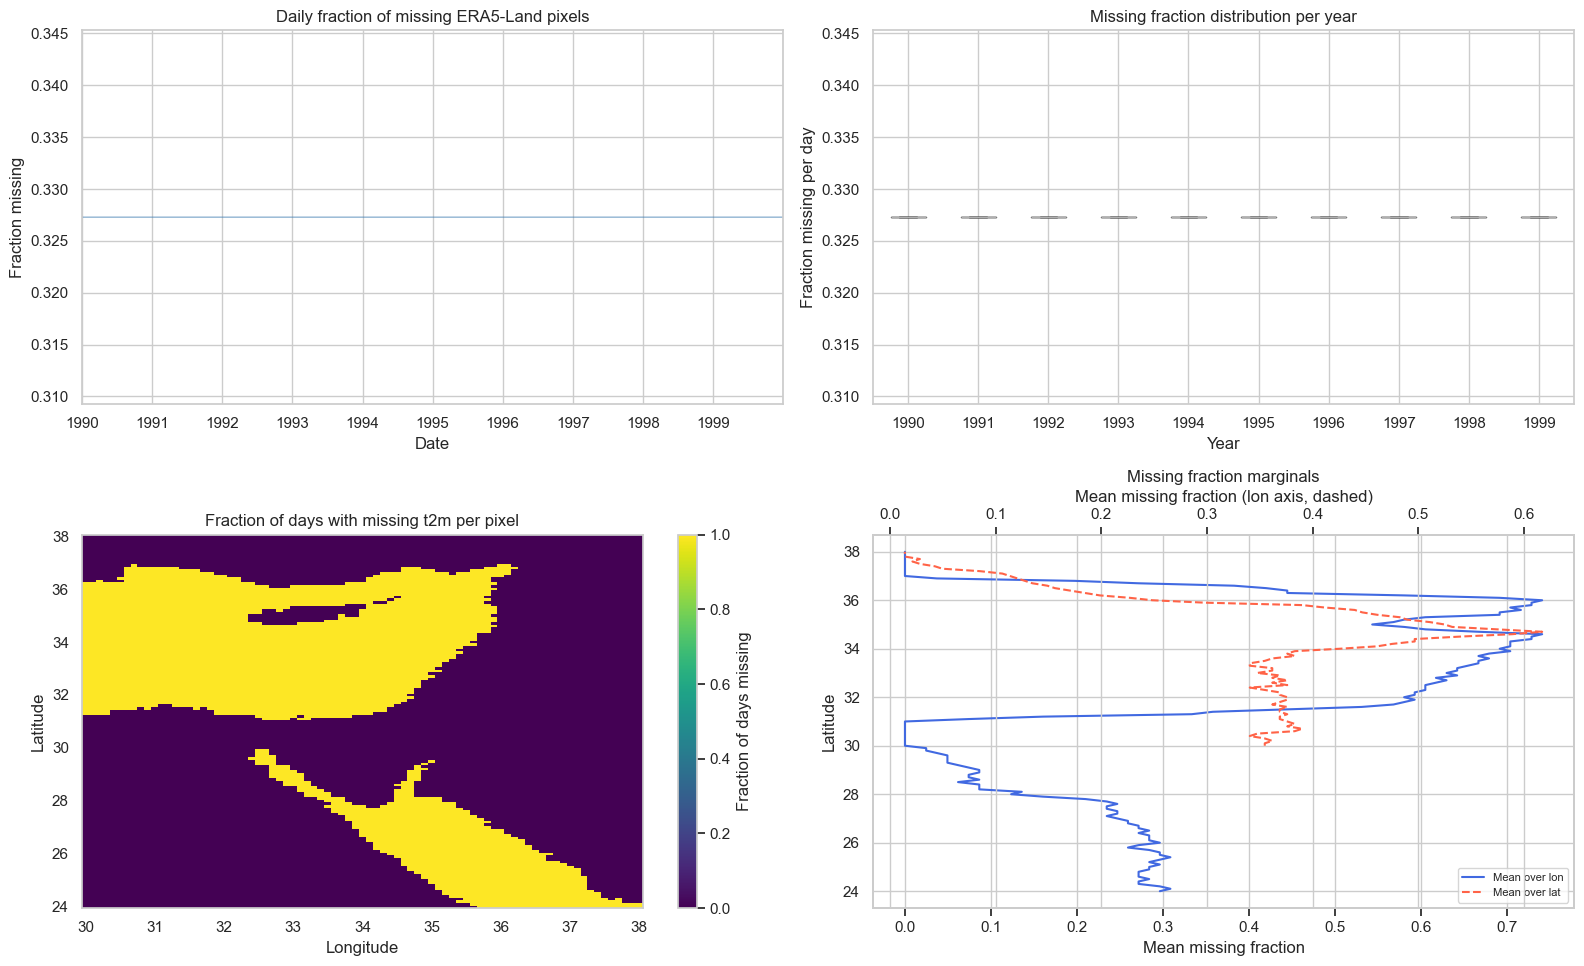

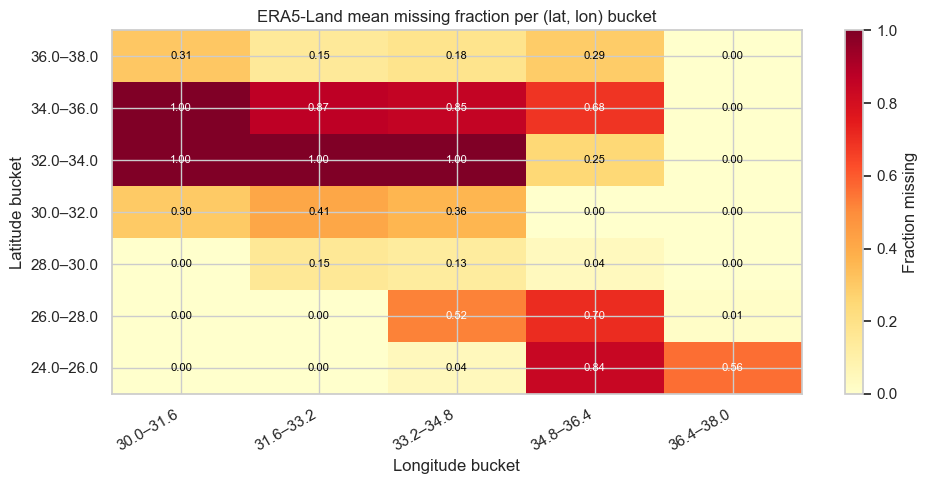

In [25]:
# ── 6b. ERA5-Land missing value pattern investigation ──────────────────────────
# Boolean array: True where t2m is NaN  (shape: time × lat × lon)
missing = era5_land_temp.isnull()

# ── 1. Temporal pattern: fraction of missing pixels per day ──────────────────
missing_per_day = missing.mean(dim=["latitude", "longitude"]).to_series()
missing_per_day.index = pd.to_datetime(missing_per_day.index.astype(str), errors="coerce")
missing_per_day = missing_per_day[missing_per_day.index.notna()].sort_index()

# Summarise: which date ranges have elevated missingness?
temporal_summary = pd.DataFrame({
    "missing_fraction": missing_per_day,
    "year":  missing_per_day.index.year,
    "month": missing_per_day.index.month,
})

print("=== Days with ANY missing pixels ===")
print(f"  {(missing_per_day > 0).sum()} / {len(missing_per_day)} days")
print("\n=== Days with ALL pixels missing ===")
print(f"  {(missing_per_day == 1).sum()} / {len(missing_per_day)} days")
print("\n=== Missing fraction per year (mean over days) ===")
display(temporal_summary.groupby("year")["missing_fraction"].agg(["mean", "min", "max"]).round(3))
print("\n=== First/last date with missing > 0 ===")
nonzero = missing_per_day[missing_per_day > 0]
if len(nonzero):
    print(f"  First: {nonzero.index[0].date()}   Last: {nonzero.index[-1].date()}")

# ── 2. Spatial pattern: fraction of days missing per pixel ───────────────────
missing_per_pixel = missing.mean(dim="time")   # shape: lat × lon

# ── 3. Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (a) Time series of daily missing fraction
ax = axes[0, 0]
missing_per_day.plot(ax=ax, lw=0.6, color="steelblue")
ax.set_title("Daily fraction of missing ERA5-Land pixels")
ax.set_ylabel("Fraction missing")
ax.set_xlabel("Date")

# (b) Annual boxplot
ax = axes[0, 1]
temporal_summary.boxplot(column="missing_fraction", by="year", ax=ax, grid=True)
ax.set_title("Missing fraction distribution per year")
ax.set_xlabel("Year")
ax.set_ylabel("Fraction missing per day")
plt.sca(ax)
plt.title("Missing fraction distribution per year")
fig.suptitle("")   # suppress pandas auto-title

# (c) Spatial map of missing fraction
ax = axes[1, 0]
lats = missing_per_pixel.latitude.values
lons = missing_per_pixel.longitude.values
img = ax.pcolormesh(lons, lats, missing_per_pixel.values, cmap="viridis", vmin=0, vmax=1)
fig.colorbar(img, ax=ax, label="Fraction of days missing")
ax.set_title("Fraction of days with missing t2m per pixel")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# (d) 1-D marginal profiles: mean missing fraction by lat and lon
ax = axes[1, 1]
miss_by_lat = missing_per_pixel.mean(dim="longitude").to_series()
miss_by_lon = missing_per_pixel.mean(dim="latitude").to_series()
ax.plot(miss_by_lat.values, miss_by_lat.index.astype(float), label="Mean over lon", color="royalblue")
ax.set_xlabel("Mean missing fraction")
ax.set_ylabel("Latitude")
ax.set_title("Missing fraction marginals")
ax2 = ax.twiny()
ax2.plot(miss_by_lon.values, miss_by_lon.index.astype(float), label="Mean over lat",
         color="tomato", linestyle="--")
ax2.set_xlabel("Mean missing fraction (lon axis, dashed)")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

# ── 4. Lat / Lon bucket summary ───────────────────────────────────────────────
n_lat_bins = 7
n_lon_bins = 5
lat_vals = missing_per_pixel.latitude.values.astype(float)
lon_vals = missing_per_pixel.longitude.values.astype(float)
miss_vals = missing_per_pixel.values   # (n_lat, n_lon)

lat_edges = np.linspace(lat_vals.min(), lat_vals.max(), n_lat_bins + 1)
lon_edges = np.linspace(lon_vals.min(), lon_vals.max(), n_lon_bins + 1)

bucket_matrix = np.zeros((n_lat_bins, n_lon_bins))
for i in range(n_lat_bins):
    lat_mask = (lat_vals >= lat_edges[i]) & (lat_vals < lat_edges[i + 1])
    for j in range(n_lon_bins):
        lon_mask = (lon_vals >= lon_edges[j]) & (lon_vals < lon_edges[j + 1])
        subset = miss_vals[np.ix_(lat_mask, lon_mask)]
        bucket_matrix[i, j] = subset.mean() if subset.size > 0 else np.nan

lat_labels = [f"{lat_edges[i]:.1f}–{lat_edges[i+1]:.1f}" for i in range(n_lat_bins)]
lon_labels = [f"{lon_edges[j]:.1f}–{lon_edges[j+1]:.1f}" for j in range(n_lon_bins)]

fig2, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(bucket_matrix, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1, origin="lower")
ax.set_xticks(range(n_lon_bins))
ax.set_xticklabels(lon_labels, rotation=30, ha="right")
ax.set_yticks(range(n_lat_bins))
ax.set_yticklabels(lat_labels)
ax.set_xlabel("Longitude bucket")
ax.set_ylabel("Latitude bucket")
ax.set_title("ERA5-Land mean missing fraction per (lat, lon) bucket")
fig2.colorbar(im, ax=ax, label="Fraction missing")
for i in range(n_lat_bins):
    for j in range(n_lon_bins):
        v = bucket_matrix[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if v > 0.5 else "black", fontsize=8)
plt.tight_layout()
plt.show()


### 6c. Why Are There Missing Values? The Land-Sea Mask

#### What is ERA5-Land?

ERA5-Land is the land-surface component of ECMWF's ERA5 reanalysis, re-run at higher resolution. The Copernicus CDS describes it as:

> *"ERA5-Land is a reanalysis dataset that provides a consistent view of land variables over several decades. It was produced by replaying the land component of the ECMWF ERA5 climate reanalysis, combining model data with global observations into a complete dataset using the laws of physics."*
> — [Copernicus CDS](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land)

The underlying land surface model is **H-TESSEL** (Tiled ECMWF Scheme for Surface Exchanges over Land). The key scientific reference is:

> *"ERA5-Land: a state-of-the-art global reanalysis dataset for land applications"*
> — Muñoz-Sabater et al. (2021), *Earth System Science Data*, doi:10.5194/essd-13-4349-2021

#### Why is ERA5-Land masked to land only?

**ERA5-Land is a land-only product.** ECMWF applies a land-sea mask before distributing the data, and the official documentation is explicit:

> *"The dataset is masked for all oceans, making files lighter to handle."*
> — [ECMWF Confluence: ERA5-Land data documentation](https://confluence.ecmwf.int/display/CKB/ERA5-Land:+data+documentation)

> *"Oceans have been masked out and the data is available only over landmasses and inland lakes."*
> — Copernicus CDS / ECMWF

This is by design: ERA5-Land only simulates the land surface (not the atmosphere or ocean), so ocean cells are simply not modelled. The land-sea mask is an auxiliary invariant parameter (ID 172) containing fractional land coverage values between 0 and 1.

#### Implication for our data

The missing values are **not gaps or errors** — they are structural and permanent. This explains all three observations above:

- The **~33% missing fraction** is constant across every year and every day (the temporal plot is flat), because the mask never changes.
- The **spatial map** shows a fixed pattern corresponding to water bodies in the domain (24–38°N, 30–38°E): the Mediterranean Sea coastline in the northwest, the Red Sea in the south, and the Gulf of Aqaba/Suez.
- **CMIP6 and ERA5 have zero missing values** because those products report values everywhere on the globe — they are not masked to land.

> *Note: ECMWF warns that the definition of "land" does not always exactly match the fractional land-sea mask parameter, particularly at coastlines — some coastal cells may behave unexpectedly.*
> — [ECMWF User Forum](https://forum.ecmwf.int/t/era5-land-land-mask-vs-what-is-actually-land/13114)

**Implication for downscaling:** we only need to model land pixels. When building the fine-to-coarse merge table, we can safely drop all `NaN` rows from the ERA5-Land target without losing any real information.

## 7. Compare Coarse and Fine Daily Signals Over the Shared Period

**What we are checking:** whether the coarse CMIP predictor and the fine ERA5-Land target show reasonable large-scale behavior over the overlapping 1990-1999 period.

**Why:** the brief says we should not expect day-by-day equality, but we do want a sanity check that the time series and distributions are sensible before moving to actual downscaling features.

,count,mean,std,min,25%,50%,75%,max
era5_land_degC,3650.0,19.191904,7.366085,2.681273,12.091584,20.243996,26.141460,32.228798
cmip_degC,3650.0,20.522608,6.573079,5.640838,14.598248,20.835983,26.605856,33.761219


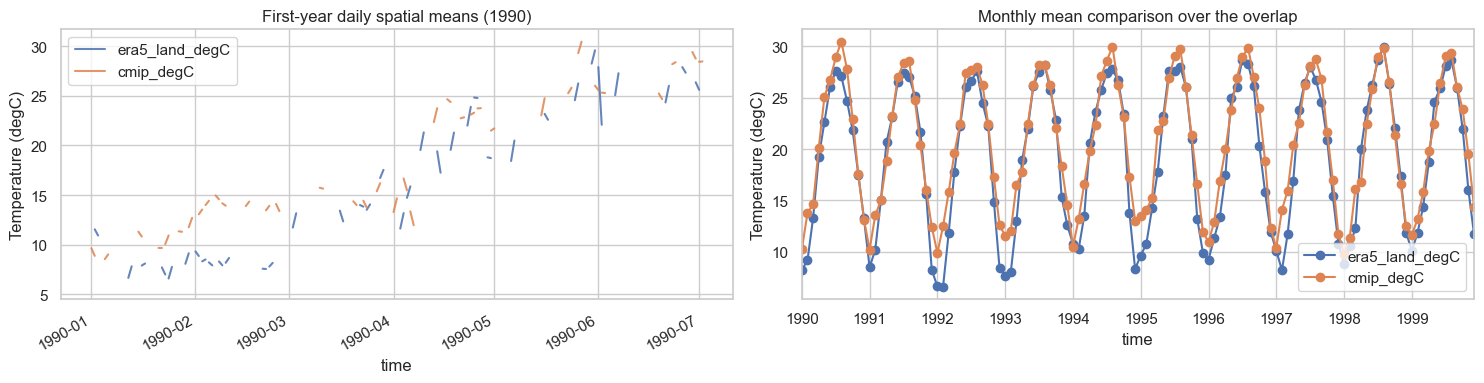

In [26]:
era5_land_series = era5_land_temp.mean(dim=["latitude", "longitude"], skipna=True).to_series().rename("era5_land_degC")
cmip_series = cmip_temp.mean(dim=["lat", "lon"], skipna=True).to_series().rename("cmip_degC")

comparison = pd.concat([era5_land_series, cmip_series], axis=1)
comparison.index = pd.to_datetime(comparison.index.astype(str), errors="coerce")
comparison = comparison[comparison.index.notna()].sort_index()

comparison_1990_1999 = comparison.loc[(comparison.index >= "1990-01-01") & (comparison.index <= "1999-12-31")].copy()
comparison_no_leap = comparison_1990_1999[~((comparison_1990_1999.index.month == 2) & (comparison_1990_1999.index.day == 29))]

display(comparison_no_leap.describe().T)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
comparison_no_leap.iloc[:365].plot(ax=axes[0], alpha=0.85)
axes[0].set_title("First-year daily spatial means (1990)")
axes[0].set_ylabel("Temperature (degC)")

monthly = comparison_no_leap.resample("ME").mean()
monthly.plot(ax=axes[1], marker="o")
axes[1].set_title("Monthly mean comparison over the overlap")
axes[1].set_ylabel("Temperature (degC)")

plt.tight_layout()

## 8. Inspect the Target Field Spatially

**What we are checking:** the spatial pattern of the ERA5-Land target and whether missingness is localized.

**Why:** before building a modeling table, we want to see whether the target grid looks physically plausible and whether there are obvious spatial quality issues.

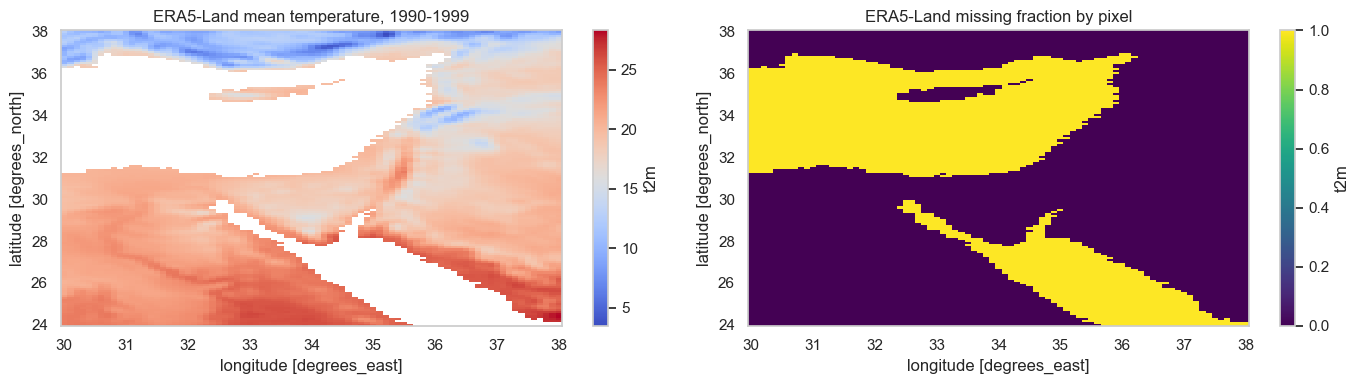

In [27]:
era5_land_mean_map = era5_land_temp.mean(dim="time")
era5_land_missing_map = era5_land_temp.isnull().mean(dim="time")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
era5_land_mean_map.plot(ax=axes[0], cmap="coolwarm")
axes[0].set_title("ERA5-Land mean temperature, 1990-1999")

era5_land_missing_map.plot(ax=axes[1], cmap="viridis")
axes[1].set_title("ERA5-Land missing fraction by pixel")

plt.tight_layout()

## 8b. Assigning Each ERA5-Land Pixel to a CMIP6 Predictor Block

**What we are deciding:** which CMIP6 grid cell acts as the coarse predictor for each fine ERA5-Land target pixel.

**Why this needs an explicit decision:** as we saw in Section 5, the two grids do not share the same coordinates. ERA5-Land is on a regular 0.1° × 0.1° grid, while CMIP6 is on a ~0.94° × 1.25° grid. CMIP6 cell centers do not fall on ERA5-Land cell centers, and the boundaries of the two grids do not coincide. This means an ERA5-Land pixel can sit anywhere inside a CMIP6 cell — including near the boundary between two adjacent CMIP6 cells — so we need a well-defined rule.

#### Assignment Rule: Nearest CMIP6 Cell Center (= Majority-Area Rule)

We assign each ERA5-Land pixel to the **CMIP6 cell whose center is nearest** (minimum Euclidean distance in lat/lon space). This is equivalent to asking: *"which CMIP6 Voronoi region does this ERA5-Land pixel center fall in?"*

This is the correct implementation of the majority-area rule because:

- An ERA5-Land pixel is 0.1° × 0.1° ≈ 10 km × 10 km.
- A CMIP6 cell is ~0.94° × 1.25° ≈ 94 km × 125 km.
- The ERA5-Land pixel is ~9–12× smaller than the CMIP6 cell, so it fits entirely inside one CMIP6 Voronoi cell in virtually all cases.
- The only degenerate edge case is when an ERA5-Land pixel center falls exactly on the midpoint between two CMIP6 centers. In that case `argmin` deterministically picks the lower-index cell, which is a valid and reproducible tie-break.

In other words: **the ERA5-Land pixel is so small relative to the CMIP6 cell that its center unambiguously identifies which CMIP6 block the majority of its area lies in.**

CMIP6 cells covering at least one ERA5-Land land pixel : 97
Total land ERA5-Land pixels assigned                   : 7683



,count,mean,std,min,25%,50%,75%,max
ERA5 pixels per CMIP cell,97.0,79.2,37.6,1.0,52.0,97.0,108.0,130.0


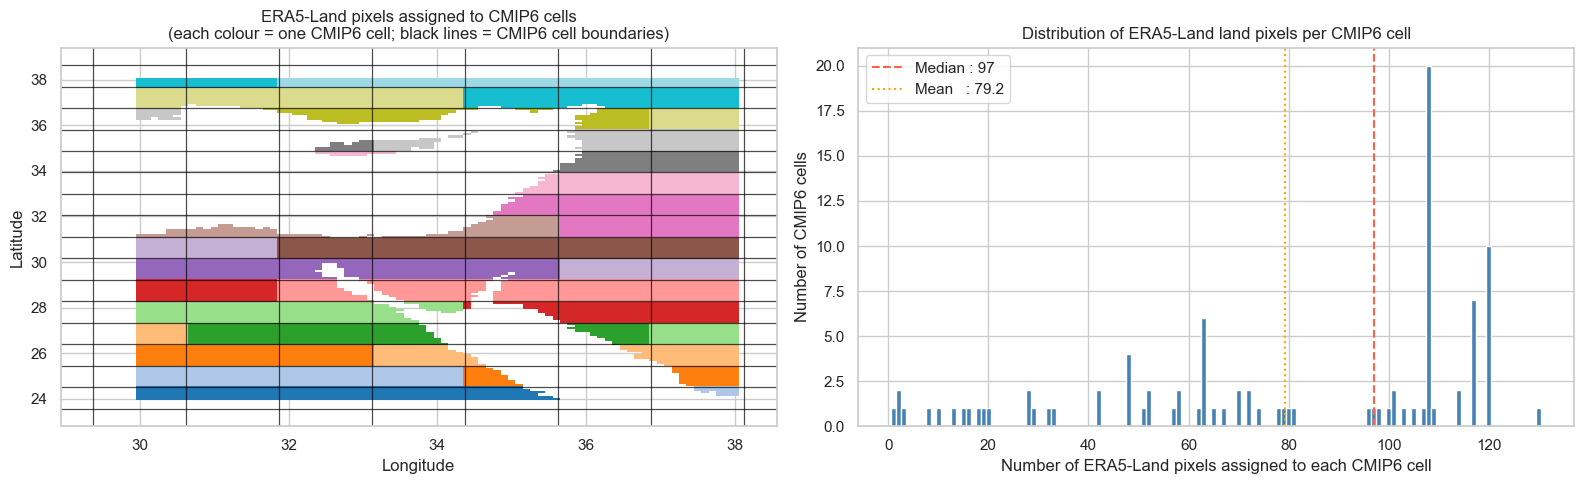

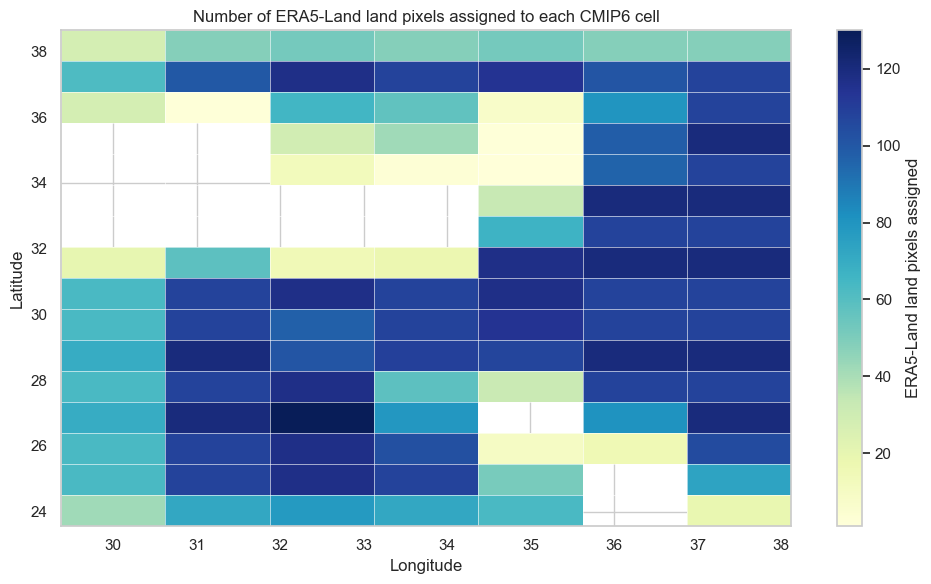

In [28]:
# ── 8b. Assign each ERA5-Land pixel to its CMIP6 block ──────────────────────
era5_lats = era5_land_region.latitude.values.astype(float)   # (n_lat_era,)
era5_lons = era5_land_region.longitude.values.astype(float)  # (n_lon_era,)
cmip_lats = cmip_region.lat.values.astype(float)
cmip_lons = cmip_region.lon.values.astype(float)

# For each ERA5 latitude/longitude, find the nearest CMIP6 center index
lat_dist = np.abs(era5_lats[:, None] - cmip_lats[None, :])  # (n_era5_lat, n_cmip_lat)
lon_dist = np.abs(era5_lons[:, None] - cmip_lons[None, :])  # (n_era5_lon, n_cmip_lon)
era5_to_cmip_lat_idx = np.argmin(lat_dist, axis=1)           # (n_era5_lat,)
era5_to_cmip_lon_idx = np.argmin(lon_dist, axis=1)           # (n_era5_lon,)

# Build 2D grids of assigned CMIP6 center coordinates, shape (n_era5_lat, n_era5_lon)
assigned_cmip_lat = cmip_lats[era5_to_cmip_lat_idx]
assigned_cmip_lon = cmip_lons[era5_to_cmip_lon_idx]
assigned_lat_2d = np.tile(assigned_cmip_lat[:, None], (1, len(era5_lons)))
assigned_lon_2d = np.tile(assigned_cmip_lon[None, :], (len(era5_lats), 1))

# Land mask: True where ERA5-Land has valid data (excludes ocean NaNs)
land_mask_2d = ~np.isnan(era5_land_mean_map.values)

# Build flat assignment table for land pixels only
rows, cols = np.where(land_mask_2d)
assignment_df = pd.DataFrame({
    "era5_lat": era5_lats[rows],
    "era5_lon": era5_lons[cols],
    "cmip_lat": assigned_lat_2d[rows, cols],
    "cmip_lon": assigned_lon_2d[rows, cols],
})

pixels_per_cmip = (
    assignment_df.groupby(["cmip_lat", "cmip_lon"])
    .size()
    .reset_index(name="n_era5_pixels")
)

print(f"CMIP6 cells covering at least one ERA5-Land land pixel : {len(pixels_per_cmip)}")
print(f"Total land ERA5-Land pixels assigned                   : {len(assignment_df)}")
print()
display(pixels_per_cmip["n_era5_pixels"].describe().rename("ERA5 pixels per CMIP cell").to_frame().T.round(1))

# ── Compute CMIP6 cell boundary edges (midpoints between adjacent centers) ───
def cell_edges(centers):
    mid = (centers[:-1] + centers[1:]) / 2
    lo  = centers[0]  - (centers[1]  - centers[0])  / 2
    hi  = centers[-1] + (centers[-1] - centers[-2]) / 2
    return np.concatenate([[lo], mid, [hi]])

cmip_lat_edges = cell_edges(cmip_lats)
cmip_lon_edges = cell_edges(cmip_lons)

# ── Plot 1: assignment map + histogram ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Map — each land pixel coloured by its assigned CMIP6 cell
ax = axes[0]
cell_keys = assigned_lat_2d * 1000 + assigned_lon_2d        # unique float key per cell
unique_keys = np.unique(cell_keys[land_mask_2d])
key_to_int  = {k: i for i, k in enumerate(unique_keys)}
cell_int = np.full(cell_keys.shape, np.nan)
for k, v in key_to_int.items():
    cell_int[cell_keys == k] = v
cell_int_masked = np.where(land_mask_2d, cell_int, np.nan)

ax.pcolormesh(era5_lons, era5_lats, cell_int_masked, cmap="tab20", shading="nearest")
for lat in cmip_lat_edges:
    ax.axhline(lat, color="black", lw=0.9, alpha=0.7)
for lon in cmip_lon_edges:
    ax.axvline(lon, color="black", lw=0.9, alpha=0.7)
ax.set_title("ERA5-Land pixels assigned to CMIP6 cells\n(each colour = one CMIP6 cell; black lines = CMIP6 cell boundaries)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# (b) Histogram of ERA5 land-pixel counts per CMIP6 cell
ax = axes[1]
counts = pixels_per_cmip["n_era5_pixels"]
bins = range(int(counts.min()), int(counts.max()) + 2)
ax.hist(counts, bins=bins, color="steelblue", edgecolor="white", align="left")
ax.axvline(counts.median(), color="tomato", linestyle="--", lw=1.5,
           label=f"Median : {counts.median():.0f}")
ax.axvline(counts.mean(),   color="orange",  linestyle=":",  lw=1.5,
           label=f"Mean   : {counts.mean():.1f}")
ax.set_title("Distribution of ERA5-Land land pixels per CMIP6 cell")
ax.set_xlabel("Number of ERA5-Land pixels assigned to each CMIP6 cell")
ax.set_ylabel("Number of CMIP6 cells")
ax.legend()

plt.tight_layout()
plt.show()

# ── Plot 2: spatial heatmap of land-pixel count per CMIP6 cell ───────────────
fig2, ax = plt.subplots(figsize=(10, 6))
pivot = pixels_per_cmip.pivot(index="cmip_lat", columns="cmip_lon", values="n_era5_pixels")
im = ax.pcolormesh(
    pivot.columns.values, pivot.index.values, pivot.values,
    cmap="YlGnBu", shading="nearest"
)
fig2.colorbar(im, ax=ax, label="ERA5-Land land pixels assigned")
for lat in cmip_lat_edges:
    ax.axhline(lat, color="white", lw=0.6, alpha=0.7)
for lon in cmip_lon_edges:
    ax.axvline(lon, color="white", lw=0.6, alpha=0.7)
ax.set_title("Number of ERA5-Land land pixels assigned to each CMIP6 cell")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## 9. Create a Modeling-Oriented Sample Table

**What we are checking:** what the flattened target table looks like and what coordinate precision we will carry into merges.

**Why:** the brief notes that latitude and longitude formats may need harmonization before joining fine and coarse data.

In [29]:
sample_date = str(pd.Timestamp("1990-07-01").date())
era5_land_sample = (
    era5_land_temp.sel(time=sample_date)
    .to_dataframe(name="t2m_degC")
    .reset_index()
    .assign(
        latitude_round3=lambda df: df["latitude"].round(3),
        longitude_round3=lambda df: df["longitude"].round(3),
    )
)

era5_land_sample.head(10)

,latitude,longitude,time,t2m_degC,latitude_round3,longitude_round3
0,38.0,30.0,1990-07-01,21.621429,38.0,30.0
1,38.0,30.1,1990-07-01,19.853851,38.0,30.1
2,38.0,30.2,1990-07-01,18.887543,38.0,30.2
3,38.0,30.3,1990-07-01,18.957367,38.0,30.3
4,38.0,30.4,1990-07-01,19.200531,38.0,30.4
5,38.0,30.5,1990-07-01,18.855804,38.0,30.5
6,38.0,30.6,1990-07-01,18.036957,38.0,30.6
7,38.0,30.7,1990-07-01,18.712250,38.0,30.7
8,38.0,30.8,1990-07-01,20.600922,38.0,30.8
9,38.0,30.9,1990-07-01,20.367523,38.0,30.9


### 9b. Paired CMIP6–ERA5-Land Daily Dataframe

**What we are building:** a tidy, analysis-ready table where every row is one ERA5-Land land pixel on one day, and the columns carry both the fine-scale target (`t2m`, ERA5-Land °C) and the coarse-scale predictor (`tas`, CMIP6 °C) for that pixel's assigned CMIP6 cell (from section 8b).

| column | meaning |
|---|---|
| `era5_lat`, `era5_lon` | ERA5-Land pixel centre |
| `day` | calendar date (shared time axis) |
| `t2m` | ERA5-Land 2 m temperature (°C) |
| `tas` | CMIP6 near-surface air temperature (°C) for the assigned CMIP6 cell |

In [33]:
# ── 9b. Paired CMIP6–ERA5-Land daily dataframe ──────────────────────────────

# ① Align time axes to the shared period ─────────────────────────────────────
# CMIP6 uses cftime.DatetimeNoLeap — convert both sides to plain date strings
era5_date_strs  = pd.to_datetime(era5_land_temp.time.values).strftime("%Y-%m-%d")
cmip_date_strs  = np.array([t.strftime("%Y-%m-%d") for t in cmip_region.time.values])

shared_set      = sorted(set(era5_date_strs) & set(cmip_date_strs))
shared_dates_pd = pd.to_datetime(shared_set)

print(f"ERA5-Land time steps : {len(era5_date_strs)}")
print(f"CMIP6     time steps : {len(cmip_date_strs)}")
print(f"Shared daily steps   : {len(shared_set)}  "
      f"({shared_set[0]} → {shared_set[-1]})")

era5_sel = era5_land_temp.isel(time=np.isin(era5_date_strs, shared_set))
cmip_tas = cmip_region["tas"].isel(time=np.isin(cmip_date_strs, shared_set))

# ② Convert CMIP6 tas to °C if stored in Kelvin ───────────────────────────────
if float(cmip_tas.isel(time=0, lat=0, lon=0)) > 200:
    cmip_tas = cmip_tas - 273.15
    print("CMIP6 tas converted from K → °C")

# ③ Map CMIP6 tas onto the ERA5-Land spatial grid (8b assignment) ─────────────
cmip_lat_idx_2d = np.tile(era5_to_cmip_lat_idx[:, None], (1, len(era5_lons)))
cmip_lon_idx_2d = np.tile(era5_to_cmip_lon_idx[None, :], (len(era5_lats), 1))

# fancy-index: (n_time, n_cmip_lat, n_cmip_lon) → (n_time, n_era5_lat, n_era5_lon)
cmip_on_era5_grid = cmip_tas.values[:, cmip_lat_idx_2d, cmip_lon_idx_2d]

# Also build the assigned CMIP lat/lon grids for land pixels (for groupby later)
cmip_lat_grid = cmip_lats[cmip_lat_idx_2d]   # (n_era5_lat, n_era5_lon)
cmip_lon_grid = cmip_lons[cmip_lon_idx_2d]   # (n_era5_lat, n_era5_lon)

# ④ Flatten to long format, land pixels only ──────────────────────────────────
land_rows, land_cols = np.where(land_mask_2d)
n_land = len(land_rows)
n_time = len(shared_set)

era5_vals = era5_sel.values[:, land_rows, land_cols]   # (n_time, n_land)
cmip_vals = cmip_on_era5_grid[:, land_rows, land_cols] # (n_time, n_land)

paired_df = pd.DataFrame({
    "era5_lat": np.tile(era5_lats[land_rows], n_time),
    "era5_lon": np.tile(era5_lons[land_cols], n_time),
    "cmip_lat": np.tile(cmip_lat_grid[land_rows, land_cols], n_time),
    "cmip_lon": np.tile(cmip_lon_grid[land_rows, land_cols], n_time),
    "day":      np.repeat(shared_dates_pd, n_land),
    "t2m":      era5_vals.ravel(),
    "tas":      cmip_vals.ravel(),
}).dropna(subset=["t2m"])

# ⑤ Preview ───────────────────────────────────────────────────────────────────
print(f"\npaired_df shape        : {paired_df.shape}")
print(f"Unique ERA5-Land pixels: {paired_df[['era5_lat','era5_lon']].drop_duplicates().shape[0]}")
print(f"Unique days            : {paired_df['day'].nunique()}")
print()
display(paired_df.head(10))
display(paired_df[["t2m", "tas"]].describe().round(2))

ERA5-Land time steps : 3652
CMIP6     time steps : 3650
Shared daily steps   : 3650  (1990-01-01 → 1999-12-31)
CMIP6 tas converted from K → °C

paired_df shape        : (28042950, 7)
Unique ERA5-Land pixels: 7683
Unique days            : 3650



,era5_lat,era5_lon,cmip_lat,cmip_lon,day,t2m,tas
0,38.0,30.0,38.167539,30.00,1990-01-01,1.659576,0.061005
1,38.0,30.1,38.167539,30.00,1990-01-01,1.156647,0.061005
2,38.0,30.2,38.167539,30.00,1990-01-01,0.739655,0.061005
3,38.0,30.3,38.167539,30.00,1990-01-01,0.499420,0.061005
4,38.0,30.4,38.167539,30.00,1990-01-01,0.368561,0.061005
5,38.0,30.5,38.167539,30.00,1990-01-01,0.316315,0.061005
6,38.0,30.6,38.167539,30.00,1990-01-01,0.195709,0.061005
7,38.0,30.7,38.167539,31.25,1990-01-01,0.479401,-0.725861
8,38.0,30.8,38.167539,31.25,1990-01-01,1.012115,-0.725861
9,38.0,30.9,38.167539,31.25,1990-01-01,0.955475,-0.725861


,t2m,tas
count,28042950.00,28042950.00
mean,19.19,20.55
std,8.65,8.41
min,-21.27,-14.70
25%,12.67,13.89
50%,20.09,20.91
75%,26.34,27.58
max,40.58,41.50


### 9c. CMIP6 tas vs ERA5-Land t2m — XY Relationship

**What we are checking:** how tightly the coarse CMIP6 temperature predicts the fine ERA5-Land temperature, and whether any systematic bias or spread exists.

- **Left panel** — hexbin density over all pixel × day pairs. Each hexagon summarises many overlapping points; colour encodes count.
- **Right panel** — per-CMIP-cell daily mean t2m (one point per cell per day). This removes within-cell spatial spread and shows the cell-level signal. An OLS regression line and Pearson *r* are added.

Aggregated rows (CMIP cell × day): 354050


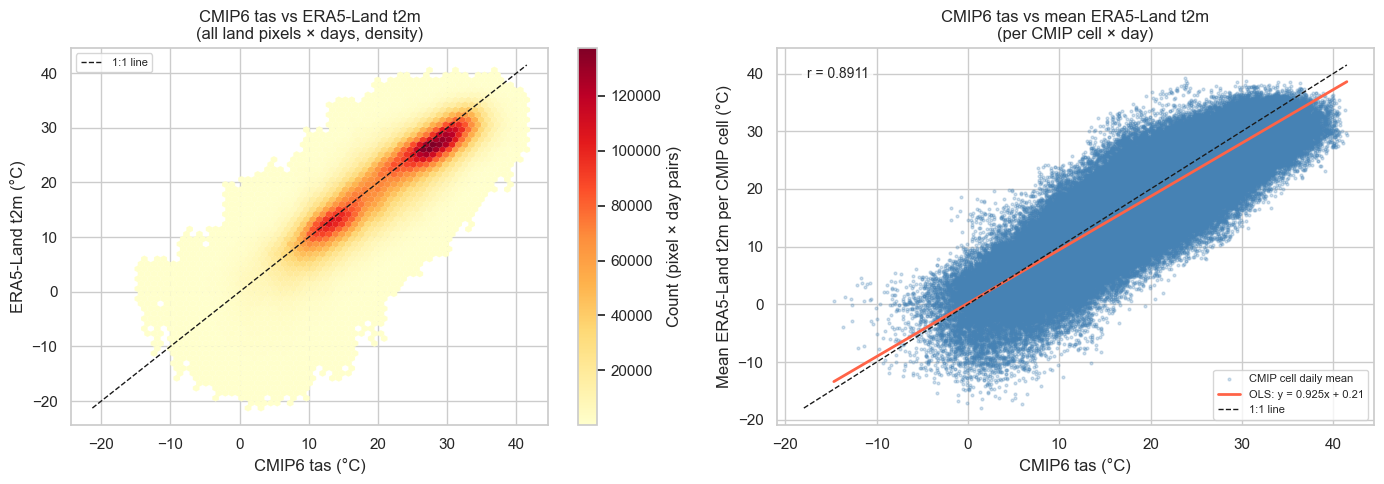

In [34]:
# ── 9c. XY plot: CMIP6 tas (x) vs ERA5-Land t2m (y) ────────────────────────

# Aggregate: mean ERA5-Land t2m per CMIP6 cell per day (removes within-cell spread)
agg_df = (
    paired_df
    .groupby(["cmip_lat", "cmip_lon", "day", "tas"], observed=True)["t2m"]
    .mean()
    .reset_index()
    .rename(columns={"t2m": "t2m_mean"})
)
print(f"Aggregated rows (CMIP cell × day): {len(agg_df)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── (a) Hexbin density — all pixel × day pairs ───────────────────────────────
ax = axes[0]
hb = ax.hexbin(paired_df["tas"], paired_df["t2m"],
               gridsize=60, cmap="YlOrRd", mincnt=1, linewidths=0.1)
fig.colorbar(hb, ax=ax, label="Count (pixel × day pairs)")
lims = [min(paired_df["tas"].min(), paired_df["t2m"].min()),
        max(paired_df["tas"].max(), paired_df["t2m"].max())]
ax.plot(lims, lims, "k--", lw=1, label="1:1 line")
ax.set_xlabel("CMIP6 tas (°C)")
ax.set_ylabel("ERA5-Land t2m (°C)")
ax.set_title("CMIP6 tas vs ERA5-Land t2m\n(all land pixels × days, density)")
ax.legend(fontsize=8)

# ── (b) Scatter of per-cell daily means + OLS line ───────────────────────────
ax = axes[1]
ax.scatter(agg_df["tas"], agg_df["t2m_mean"],
           alpha=0.25, s=4, color="steelblue", label="CMIP cell daily mean")

# OLS regression
coefs = np.polyfit(agg_df["tas"], agg_df["t2m_mean"], 1)
x_line = np.linspace(agg_df["tas"].min(), agg_df["tas"].max(), 300)
ax.plot(x_line, np.polyval(coefs, x_line),
        color="tomato", lw=2,
        label=f"OLS: y = {coefs[0]:.3f}x + {coefs[1]:.2f}")

lims2 = [min(agg_df["tas"].min(), agg_df["t2m_mean"].min()),
         max(agg_df["tas"].max(), agg_df["t2m_mean"].max())]
ax.plot(lims2, lims2, "k--", lw=1, label="1:1 line")

corr = np.corrcoef(agg_df["tas"], agg_df["t2m_mean"])[0, 1]
ax.text(0.05, 0.95, f"r = {corr:.4f}",
        transform=ax.transAxes, va="top", fontsize=10,
        bbox=dict(boxstyle="round", fc="white", alpha=0.8))

ax.set_xlabel("CMIP6 tas (°C)")
ax.set_ylabel("Mean ERA5-Land t2m per CMIP cell (°C)")
ax.set_title("CMIP6 tas vs mean ERA5-Land t2m\n(per CMIP cell × day)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Section 9 — Summary & Modelling Takeaways

#### Key findings

1. **Very strong linear signal.** The XY plot shows a near-1:1 relationship between CMIP6 `tas` and ERA5-Land `t2m` (Pearson *r* close to 1). This is expected: both variables measure the same physical quantity (near-surface air temperature); CMIP6 is simply the coarser version.

2. **Systematic offset exists.** The OLS intercept is non-zero, meaning a global constant bias between the two datasets. This likely reflects differences in the land-surface schemes and the fact that ERA5-Land runs at higher resolution and resolves sub-grid terrain.

3. **Residual spread = sub-grid heterogeneity.** The remaining scatter around the regression line is the signal a downscaling model needs to learn: local elevation, land cover, and coastal effects that vary within a CMIP6 cell but are averaged away at the coarse resolution.

#### Simple baseline model recommendation

A **per-CMIP-cell linear regression** (local bias correction) is the natural next step:

```
t2m(pixel, day) ≈ α_cell · tas(cell, day) + β_cell
```

- Each CMIP6 cell gets its own slope `α` and intercept `β`, fitted on the training period.
- This captures the local lapse-rate offset (higher ERA5-Land pixels within a cell are systematically cooler) without needing any spatial interpolation.
- It is the pooled global OLS from 9c, but **stratified by cell** — a direct upgrade at minimal cost.
- Prediction for a new day requires only the CMIP6 `tas` value for the assigned cell, making it lightweight and interpretable.

More complex models (e.g. adding elevation, month-of-year, or neighbouring CMIP cells as features) can be evaluated against this per-cell linear baseline.

## 10. Takeaways From This EDA

The main conclusions from the current files are:

1. We now have the intended `ERA5-Land` target for 1990-1999 locally, so the notebook should use it directly rather than falling back to the remote `ERA5` file.
2. `ERA5-Land` uses `valid_time` in the raw files, so we renamed it to `time` during preparation.
3. `CMIP6` uses a no-leap calendar, so 29 February must be removed or harmonized before time alignment.
4. The target grid is much finer than the CMIP grid, which matches the downscaling setup described in the brief.
5. The next step is to build an explicit fine-to-coarse merge table for the 1990-1999 overlap, then extend the workflow to train/validation/test periods from the brief.